In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import listdir
from PIL import Image
import pickle
import cv2
import time    
import os
%matplotlib inline

2024-10-18 12:45:16.230437: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s,1)}"

def augment_data(file_dir, n_generated_samples, save_to_dir):
    data_gen = ImageDataGenerator(rotation_range=15, 
                                  width_shift_range=0.15, 
                                  height_shift_range=0.15, 
                                  horizontal_flip=True, 
                                  vertical_flip=True, 
                                  fill_mode='nearest'
                                 )

    
    for filename in listdir(file_dir):
        # load the image
    
        image = cv2.imread(file_dir + '/' + filename)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # reshape the image
        image = image.reshape((1,)+image.shape)
        # prefix of the names for the generated sampels.
        save_prefix = 'aug_' + filename[:-4]
        # generate 'n_generated_samples' sample images
        i=0
        for batch in data_gen.flow(x=image, batch_size=1, save_to_dir=save_to_dir, 
                                           save_prefix=save_prefix, save_format='png'):
            i += 1
            if i > n_generated_samples:
                break

def augment_image(data_path, label, aug_num):

    start_time = time.time()
    # path to save augmented image
    augmented_data_path_from = os.path.join(data_path, 'original', 'train')
    augmented_data_path_to = os.path.join(data_path, 'augmented', 'train')

    for i in range(0, len(label)):
        folder_from = os.path.join(augmented_data_path_from, label[i])
        folder_to = os.path.join(augmented_data_path_to, label[i])
        augment_data(file_dir=folder_from, n_generated_samples=aug_num[i], save_to_dir=folder_to)
    
    end_time = time.time()

    execution_time = (end_time - start_time)
    print(f"Elapsed time: {hms_string(execution_time)}")

    data_summary(augmented_data_path_to, label)
    

    augmented_data_path_from = os.path.join(data_path, 'original', 'val')
    augmented_data_path_to = os.path.join(data_path, 'augmented', 'val')

    for i in label:
        folderPath_from = os.path.join(augmented_data_path_from,i)
        folderPath_to = os.path.join(augmented_data_path_to,i)
        num = 1
        for file in tqdm(os.listdir(folderPath_from)):
            file = cv2.imread(os.path.join(folderPath_from, file))
            file = cv2.cvtColor(file, cv2.COLOR_BGR2RGB)      
            a = str(f'{i}-{num}.png')
            plt.imsave(os.path.join(folderPath_to, a), file)
            num = num + 1

def data_summary(main_path, label):
    m = 0
    num = []
    for i in label:
        path = os.path.join(main_path, i)
        num.append(len(listdir(path)))
        m = m + len(listdir(path))

    print(f"Number of examples: {m}")
    for i in range(0, len(label)):
        prec = (num[i]* 100.0) / m
        print(f"Percentage of {label[i]} examples: {prec}%, number of {label[i]} examples: {num[i]}")

In [3]:
augment_image('/root/autodl-tmp/datasets', ['cat', 'dog'], [3, 3])

Elapsed time: 0:11:23.1
Number of examples: 7997
Percentage of cat examples: 50.00625234462924%, number of cat examples: 3999
Percentage of dog examples: 49.99374765537076%, number of dog examples: 3998


100%|██████████| 1000/1000 [01:19<00:00, 12.57it/s]


In [16]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict


def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)


def save_images_to_folders(data_batch, batch_labels, save_dir, num):
    
    label_ = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    for i, (image_data, label) in enumerate(zip(data_batch, batch_labels)):
        
        image = image_data.reshape(3, 32, 32).transpose(1, 2, 0) 
        image = Image.fromarray(image)  

        label_name = label_[label]
        label_folder = os.path.join(save_dir, label_name)
        create_folder(label_folder)
        
        image.save(os.path.join(label_folder, f'{i}{num}.png'))

for i in range(1, 6):
    batch = unpickle(f'/root/autodl-tmp/cifar10/cifar-10-batches-py/data_batch_{i}')
    data = batch[b'data']  
    labels = batch[b'labels'] 
    save_images_to_folders(data, labels, '/root/autodl-tmp/cifar10/original/train', i)

[5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]


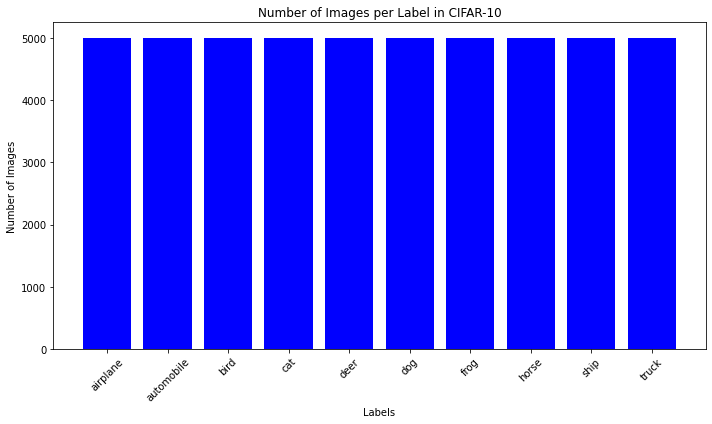

In [18]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

train_path = '/root/autodl-tmp/cifar10/original/train'

label_counts = []
for label in labels:
    label_folder = os.path.join(train_path, label)
    if os.path.exists(label_folder):
        label_counts.append(len(os.listdir(label_folder)))
    else:
        label_counts.append(0)
print(label_counts)


plt.figure(figsize=(10, 6))
plt.bar(labels, label_counts, color='blue')
plt.xlabel('Labels')
plt.ylabel('Number of Images')
plt.title('Number of Images per Label in CIFAR-10')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
batch = unpickle(f'/root/autodl-tmp/cifar10/cifar-10-batches-py/test_batch')
data = batch[b'data']  
labels = batch[b'labels'] 
save_images_to_folders(data, labels, '/root/autodl-tmp/cifar10/original/test', 0)

[1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


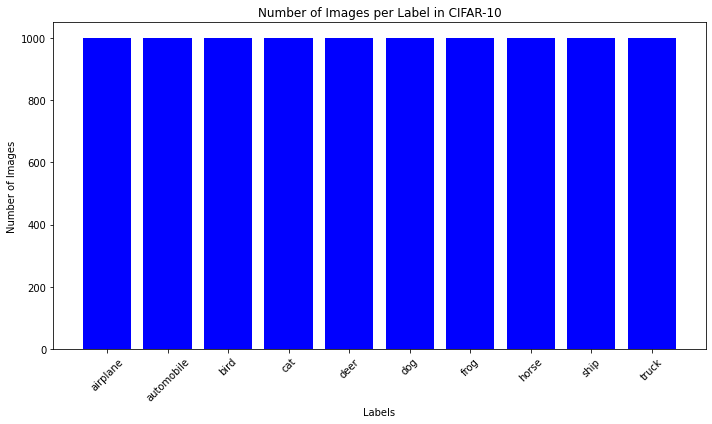

In [20]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

train_path = '/root/autodl-tmp/cifar10/original/test'

label_counts = []
for label in labels:
    label_folder = os.path.join(train_path, label)
    if os.path.exists(label_folder):
        label_counts.append(len(os.listdir(label_folder)))
    else:
        label_counts.append(0)
print(label_counts)


plt.figure(figsize=(10, 6))
plt.bar(labels, label_counts, color='blue')
plt.xlabel('Labels')
plt.ylabel('Number of Images')
plt.title('Number of Images per Label in CIFAR-10')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()